Shape: (2132, 2549)
Label categories: ['NEGATIVE' 'NEUTRAL' 'POSITIVE']

Classification Report:
              precision    recall  f1-score   support

    NEGATIVE       0.90      0.99      0.94       143
     NEUTRAL       0.99      0.97      0.98       148
    POSITIVE       0.94      0.88      0.91       136

    accuracy                           0.94       427
   macro avg       0.95      0.94      0.94       427
weighted avg       0.95      0.94      0.94       427


Predicted Mood for Sample 200: NEUTRAL

✅ Accuracy Score: 0.9438


<Figure size 600x500 with 0 Axes>

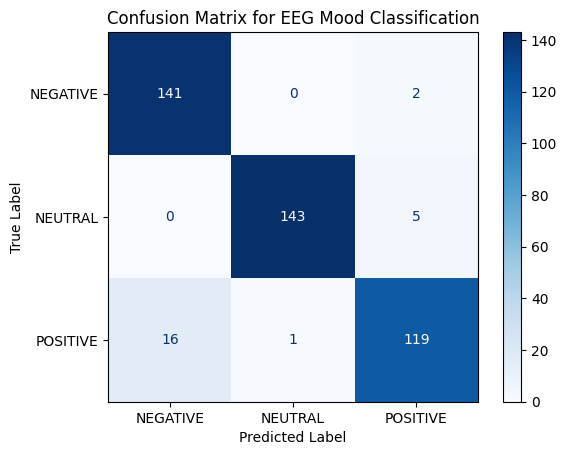


🎯 Predicted Mood: NEUTRAL

🎧 Now Playing: C:\Users\hari7\Documents\Semester 3\BCI\Music\Nee-Kavithaigala.mp3 (for 15 seconds)
⏹️ Music stopped after 15 seconds.


In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

import random

# Step 1: Load Dataset
df = pd.read_csv(r"C:\Users\hari7\Documents\Semester 3\BCI\archive (9)\emotions.csv")
print("Shape:", df.shape)
print("Label categories:", df['label'].unique())

# Step 2: Feature/Label Split
X = df.drop('label', axis=1)
y = df['label']

# Step 3: Label Encoding
le = LabelEncoder()
y_encoded = le.fit_transform(y)  # POSITIVE=2, NEUTRAL=1, NEGATIVE=0

# Step 4: Standardize Features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 5: Dimensionality Reduction (optional, keeps top 100 principal components)
pca = PCA(n_components=100)
X_pca = pca.fit_transform(X_scaled)

# Step 6: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_pca, y_encoded, test_size=0.2, random_state=42)

# Step 7: Train Classifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Step 8: Evaluate
y_pred = model.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Step 9: Predict a Sample & Recommend Music
sample_index = random.randint(0, X_test.shape[0] - 1)
predicted_label = model.predict([X_test[sample_index]])[0]
predicted_mood = le.inverse_transform([predicted_label])[0]

print(f"\nPredicted Mood for Sample {sample_index}: {predicted_mood}")

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt

# Accuracy Score
acc = accuracy_score(y_test, y_pred)
print(f"\n✅ Accuracy Score: {acc:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)

# Plotting
plt.figure(figsize=(6, 5))
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix for EEG Mood Classification")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.grid(False)
plt.show()


import pygame
import time
import random

sample_index = random.randint(0, X_test.shape[0] - 1)
predicted_class = model.predict([X_test[sample_index]])[0]
predicted_mood = le.inverse_transform([predicted_class])[0]
print(f"\n🎯 Predicted Mood: {predicted_mood}")

# === Map Mood to Local Music File ===
mood_to_song = {
    'POSITIVE': r"C:\Users\hari7\Documents\Semester 3\BCI\Music\Azhagiye.mp3",
    'NEUTRAL':  r"C:\Users\hari7\Documents\Semester 3\BCI\Music\Nee-Kavithaigala.mp3",
    'NEGATIVE': r"C:\Users\hari7\Documents\Semester 3\BCI\Music\Tere Bina Guru 320 Kbps.mp3"
}

# === Play the Song ===
# === Play the Song for 15 Seconds ===
pygame.mixer.init()
song_path = mood_to_song[predicted_mood]

print(f"\n🎧 Now Playing: {song_path} (for 15 seconds)")
pygame.mixer.music.load(song_path)
pygame.mixer.music.play()

# Wait 15 seconds
time.sleep(15)

# Stop the music
pygame.mixer.music.stop()
print("⏹️ Music stopped after 15 seconds.")



In [ ]:
import pygame
import time
import random

sample_index = random.randint(0, X_test.shape[0] - 1)
predicted_class = model.predict([X_test[sample_index]])[0]
predicted_mood = le.inverse_transform([predicted_class])[0]
print(f"\n🎯 Predicted Mood: {predicted_mood}")

# === Map Mood to Local Music File ===
mood_to_song = {
    'POSITIVE': r"C:\Users\hari7\Documents\Semester 3\BCI\Music\Azhagiye.mp3",
    'NEUTRAL':  r"C:\Users\hari7\Documents\Semester 3\BCI\Music\Nee-Kavithaigala.mp3",
    'NEGATIVE': r"C:\Users\hari7\Documents\Semester 3\BCI\Music\Tere Bina Guru 320 Kbps.mp3"
}

# === Play the Song ===
# === Play the Song for 15 Seconds ===
pygame.mixer.init()
song_path = mood_to_song[predicted_mood]

print(f"\n🎧 Now Playing: {song_path} (for 15 seconds)")

pygame.mixer.music.load(song_path)
pygame.mixer.music.play()

# Wait 15 seconds
time.sleep(10)

# Stop the music
pygame.mixer.music.stop()
print("⏹️ Music stopped after 15 seconds.")



🎯 Predicted Mood: NEUTRAL

🎧 Now Playing: C:\Users\hari7\Documents\Semester 3\BCI\Music\Nee-Kavithaigala.mp3 (for 15 seconds)


KeyboardInterrupt: 

In [4]:
import pygame
import random
import time

# Simulate EEG Prediction
def get_current_mood():
    # Replace this with your EEG model prediction
    return random.choice(['POSITIVE', 'NEUTRAL', 'NEGATIVE'])

# Initialize Pygame
pygame.init()
screen = pygame.display.set_mode((800, 600))
pygame.display.set_caption("EEG Mood Controlled Game")
clock = pygame.time.Clock()

# Color mapping for mood
colors = {
    'POSITIVE': (135, 206, 250),  # Light Blue
    'NEUTRAL': (192, 192, 192),   # Gray
    'NEGATIVE': (50, 50, 50)      # Dark
}

# Game Loop
running = True
mood = get_current_mood()  # Initial mood
last_mood_change = time.time()

while running:
    # Check Events
    for event in pygame.event.get():
        if event.type == pygame.QUIT:
            running = False

    # Update mood every 10 seconds
    if time.time() - last_mood_change > 10:
        mood = get_current_mood()
        print(f"[EEG] Mood changed to: {mood}")
        last_mood_change = time.time()

    # Set Background Color based on mood
    screen.fill(colors[mood])

    # Add some simple player / enemy logic (optional)
    # Example: Faster enemies when NEGATIVE

    # Update the display
    pygame.display.flip()
    clock.tick(10)

pygame.quit()
